# Исследование объявлений о продаже квартир

В вашем распоряжении данные сервиса Яндекс Недвижимость — архив объявлений о продаже квартир в Санкт-Петербурге и соседних населённых пунктах за несколько лет. Вам нужно научиться определять рыночную стоимость объектов недвижимости. Для этого проведите исследовательский анализ данных и установите параметры, влияющие на цену объектов. Это позволит построить автоматизированную систему: она отследит аномалии и мошенническую деятельность.

По каждой квартире на продажу доступны два вида данных. Первые вписаны пользователем, вторые — получены автоматически на основе картографических данных. Например, расстояние до центра, аэропорта и других объектов — эти данные автоматически получены из геосервисов. Количество парков и водоёмов также заполняется без участия пользователя.

### Откройте файл с данными и изучите общую информацию

Считаем данные и выведем первый 10 строк и вызовем метод info()

In [66]:
#импорт библиотек
import pandas as pd
import matplotlib.pyplot as plt

In [67]:
#открытие данных
data = pd.read_csv('/datasets/real_estate_data.csv', sep='\t')

In [68]:
#вывод таблицы на экран
pd.set_option('display.max_columns', None)
data.head(10)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,cityCenters_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition
0,20,13000000.0,108.00,2019-03-07T00:00:00,3,2.70,16.0,51.00,8,NaN,False,False,25.00,NaN,Санкт-Петербург,18863.0,16028.0,1.0,482.0,2.0,755.0,NaN
1,7,3350000.0,40.40,2018-12-04T00:00:00,1,NaN,11.0,18.60,1,NaN,False,False,11.00,2.0,посёлок Шушары,12817.0,18603.0,0.0,NaN,0.0,NaN,81.0
2,10,5196000.0,56.00,2015-08-20T00:00:00,2,NaN,5.0,34.30,4,NaN,False,False,8.30,0.0,Санкт-Петербург,21741.0,13933.0,1.0,90.0,2.0,574.0,558.0
3,0,64900000.0,159.00,2015-07-24T00:00:00,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0.0,Санкт-Петербург,28098.0,6800.0,2.0,84.0,3.0,234.0,424.0
4,2,10000000.0,100.00,2018-06-19T00:00:00,2,3.03,14.0,32.00,13,NaN,False,False,41.00,NaN,Санкт-Петербург,31856.0,8098.0,2.0,112.0,1.0,48.0,121.0
5,10,2890000.0,30.40,2018-09-10T00:00:00,1,NaN,12.0,14.40,5,NaN,False,False,9.10,NaN,городской посёлок Янино-1,NaN,NaN,NaN,NaN,NaN,NaN,55.0
6,6,3700000.0,37.30,2017-11-02T00:00:00,1,NaN,26.0,10.60,6,NaN,False,False,14.40,1.0,посёлок Парголово,52996.0,19143.0,0.0,NaN,0.0,NaN,155.0
7,5,7915000.0,71.60,2019-04-18T00:00:00,2,NaN,24.0,NaN,22,NaN,False,False,18.90,2.0,Санкт-Петербург,23982.0,11634.0,0.0,NaN,0.0,NaN,NaN
8,20,2900000.0,33.16,2018-05-23T00:00:00,1,NaN,27.0,15.43,26,NaN,False,False,8.81,NaN,посёлок Мурино,NaN,NaN,NaN,NaN,NaN,NaN,189.0
9,18,5400000.0,61.00,2017-02-26T00:00:00,3,2.50,9.0,43.60,7,NaN,False,False,6.50,2.0,Санкт-Петербург,50898.0,15008.0,0.0,NaN,0.0,NaN,289.0


In [69]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               12180 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

В данных видны пропуски в некоторых столбцах

Построем гистограмму для всех числовых столбцов таблицы

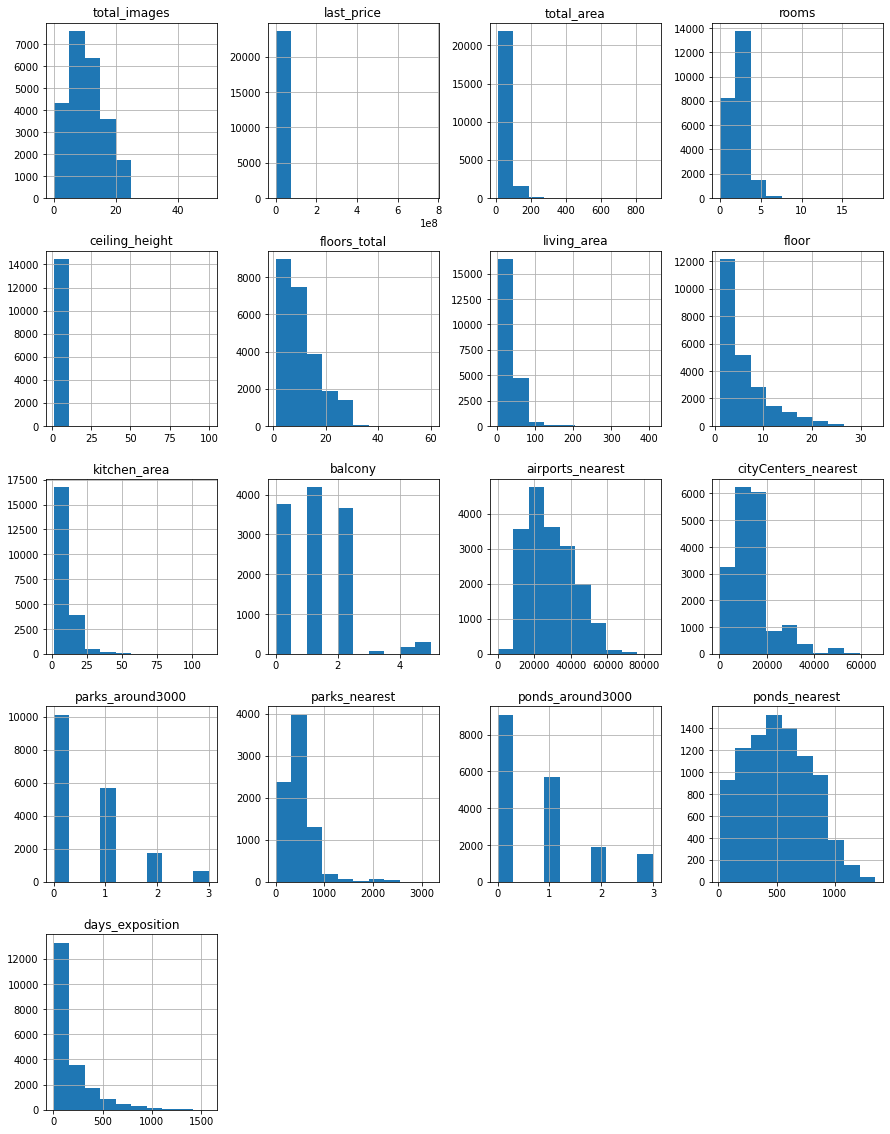

In [70]:
data.hist(figsize=(15, 20))
plt.show()

По гистограммам можно увидеть выбросы в столбцах во многих столбцах, например, `total_images`, `last+price`

In [71]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
total_images,23699.0,9.858475e+00,5.682529e+00,0.0,6.00,9.00,14.0,50.0
last_price,23699.0,6.541549e+06,1.088701e+07,12190.0,3400000.00,4650000.00,6800000.0,763000000.0
total_area,23699.0,6.034865e+01,3.565408e+01,12.0,40.00,52.00,69.9,900.0
rooms,23699.0,2.070636e+00,1.078405e+00,0.0,1.00,2.00,3.0,19.0
ceiling_height,14504.0,2.771499e+00,1.261056e+00,1.0,2.52,2.65,2.8,100.0
floors_total,23613.0,1.067382e+01,6.597173e+00,1.0,5.00,9.00,16.0,60.0
living_area,21796.0,3.445785e+01,2.203045e+01,2.0,18.60,30.00,42.3,409.7
floor,23699.0,5.892358e+00,4.885249e+00,1.0,2.00,4.00,8.0,33.0
kitchen_area,21421.0,1.056981e+01,5.905438e+00,1.3,7.00,9.10,12.0,112.0
balcony,12180.0,1.150082e+00,1.071300e+00,0.0,0.00,1.00,2.0,5.0


В исходных данных видны следующие проблемы:
- Столбец `cityCenters_nearest` записан в camelCase
- Во многих столбцах пропуски, особенно много в `ponds_nearest`, `parks_nearest`
- Во многих столбцах неверный тип данных

### Выполните предобработку данных

#### Переименование столбцов

Следует переименовать столбец `cityCenters_nearest` изменив camelCase на snake_case

In [72]:
data = data.rename(columns={'cityCenters_nearest' : 'city_centers_nearest'})

#### Работа с пропусками

Определим столбцы с пропусками

In [73]:
data.isna().sum()

total_images                0
last_price                  0
total_area                  0
first_day_exposition        0
rooms                       0
ceiling_height           9195
floors_total               86
living_area              1903
floor                       0
is_apartment            20924
studio                      0
open_plan                   0
kitchen_area             2278
balcony                 11519
locality_name              49
airports_nearest         5542
city_centers_nearest     5519
parks_around3000         5518
parks_nearest           15620
ponds_around3000         5518
ponds_nearest           14589
days_exposition          3181
dtype: int64

В столбцах `parks_nearest` и `ponds_nearest` много пропусков. Нам не особо важно точное значение в этих столбцах, поэтому категоризируем его.

Посмотрим распределение значений в этих столбцах

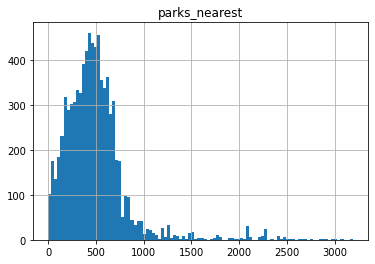

Text(0.5, 1.0, 'ponds_nearest')

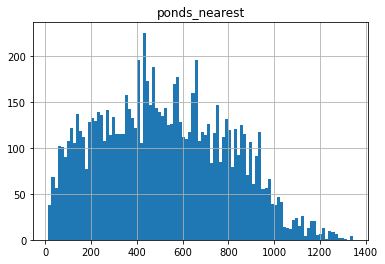

In [74]:
data['parks_nearest'].hist(bins=100)
plt.title('parks_nearest')
plt.show()
data['ponds_nearest'].hist(bins=100)
plt.title('ponds_nearest')

Сделаем следующие категории:

`parks_nearest`:
- `A` - 0-500 м
- `B` - 501-1000 м
- `C` - 1001-3000 м
- `D` - больше 3000 м

`ponds_nearest`:
- `A` - 0-600 м
- `B` - 601-1200 м
- `C` - больше 1200 м

Пропуски можно записать в категории `D` и `C` в `parks_nearest` и `ponds_nearest` соответственно, а в `parkds_around3000` и `ponds_around3000` нули, но нужно проверить, есть ли ненулевые значения об этих строках в столбцах `parks_around3000` и `ponds_around3000`

In [75]:
display(data.loc[(data['parks_nearest'].isna()) & ~(data['parks_around3000'].isna()) & ~(data['parks_around3000'] == 0), 'parks_around3000'].sum())
data.loc[(data['ponds_nearest'].isna()) & ~(data['ponds_around3000'].isna()) & ~(data['ponds_around3000'] == 0), 'ponds_around3000'].sum()

0.0

0.0

Таких значений нет, значит запишем пропуски в категории `D` и `C`

In [76]:
#категоризиируем
data['parks_category'] = data['parks_nearest'].apply(lambda n: 
                                                     'A' if 0<=n<=500 
                                                     else 'B' if 501<=n<=1000 
                                                     else 'C' if 1001<=n<=3000 
                                                     else 'D')
data['ponds_category'] = data['ponds_nearest'].apply(lambda n: 
                                                     'A' if 0<=n<=600 
                                                     else 'B' if 601<=n<=1200 
                                                     else 'C' )

Заполним пропуски в `parks_around3000` и `ponds_around3000` нулями

In [77]:
data['parks_around3000'].fillna(0, inplace=True)
data['ponds_around3000'].fillna(0, inplace=True)

Проверим категории

In [78]:
display(data[['parks_nearest', 'parks_around3000', 'parks_category']])
data[['ponds_nearest', 'ponds_around3000', 'ponds_category']]

,parks_nearest,parks_around3000,parks_category
0,482.0,1.0,A
1,NaN,0.0,D
2,90.0,1.0,A
3,84.0,2.0,A
4,112.0,2.0,A
...,...,...,...
23694,796.0,1.0,B
23695,NaN,0.0,D
23696,NaN,0.0,D
23697,173.0,2.0,A


,ponds_nearest,ponds_around3000,ponds_category
0,755.0,2.0,B
1,NaN,0.0,C
2,574.0,2.0,A
3,234.0,3.0,A
4,48.0,1.0,A
...,...,...,...
23694,381.0,3.0,A
23695,NaN,0.0,C
23696,NaN,0.0,C
23697,196.0,3.0,A


В столбце `balcony` заполним пропуски 0 так, как если кол-во балконов не указано, скорее всего их нет

In [79]:
data['balcony'].fillna(0, inplace=True)

Проверим

In [80]:
data[['balcony', 'parks_around3000', 'ponds_around3000']].isna().sum()

balcony             0
parks_around3000    0
ponds_around3000    0
dtype: int64

В столбце `balcony` пользователи скорее всего не указывали ничего, если балконов нет

В остальных столбцах причиной пропусков скорее всего является человеческий фактор или техническая ошибка

#### Работа с неправильными типами данных

In [81]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23699 entries, 0 to 23698
Data columns (total 24 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   total_images          23699 non-null  int64  
 1   last_price            23699 non-null  float64
 2   total_area            23699 non-null  float64
 3   first_day_exposition  23699 non-null  object 
 4   rooms                 23699 non-null  int64  
 5   ceiling_height        14504 non-null  float64
 6   floors_total          23613 non-null  float64
 7   living_area           21796 non-null  float64
 8   floor                 23699 non-null  int64  
 9   is_apartment          2775 non-null   object 
 10  studio                23699 non-null  bool   
 11  open_plan             23699 non-null  bool   
 12  kitchen_area          21421 non-null  float64
 13  balcony               23699 non-null  float64
 14  locality_name         23650 non-null  object 
 15  airports_nearest   

Следует поменять тип данных в столбце `first_day_exposition` (object -> datetime)

В столбце `is_apartment` можно было бы поменять тип данных на bool, но тогда значения NaN станут False, чего допускать нельзя

In [82]:
#Выведем уникальные значения столбца first_day_exposition чтобы понять тип записи
data['first_day_exposition'].unique()

array(['2019-03-07T00:00:00', '2018-12-04T00:00:00',
       '2015-08-20T00:00:00', ..., '2014-12-29T00:00:00',
       '2016-09-12T00:00:00', '2015-07-19T00:00:00'], dtype=object)

In [83]:
#приводим к типу datetime
data['first_day_exposition'] = pd.to_datetime(data['first_day_exposition'], format='%Y-%m-%dT%H:%M:%S')

В столбцах `last_price`, `floors_total`, `balcony`, `parks_around3000`, `ponds_around3000` и `days_exposition` можно заменить тип данных на целочисленный, но только в тех, в которых нет пропусков, так как тип int не поддерживает NaN

In [84]:
for col in ['last_price', 'floors_total', 'balcony', 'parks_around3000', 'ponds_around3000', 'days_exposition']:
    if data[col].isna().sum() == 0:
        data[col] = data[col].astype('int64')
        print(f'Тип данных изменён на int64 в столбце {col}')

Тип данных изменён на int64 в столбце last_price
Тип данных изменён на int64 в столбце balcony
Тип данных изменён на int64 в столбце parks_around3000
Тип данных изменён на int64 в столбце ponds_around3000


#### Работа с явными дубликатами

In [85]:
data.duplicated().sum()

0

Явных дубликатов нет

#### Работа с неявными дубликатами

In [86]:
#выведем уникальные значения столбца locality_name
data['locality_name'].unique()

array(['Санкт-Петербург', 'посёлок Шушары', 'городской посёлок Янино-1',
       'посёлок Парголово', 'посёлок Мурино', 'Ломоносов', 'Сертолово',
       'Петергоф', 'Пушкин', 'деревня Кудрово', 'Коммунар', 'Колпино',
       'поселок городского типа Красный Бор', 'Гатчина', 'поселок Мурино',
       'деревня Фёдоровское', 'Выборг', 'Кронштадт', 'Кировск',
       'деревня Новое Девяткино', 'посёлок Металлострой',
       'посёлок городского типа Лебяжье',
       'посёлок городского типа Сиверский', 'поселок Молодцово',
       'поселок городского типа Кузьмоловский',
       'садовое товарищество Новая Ропша', 'Павловск',
       'деревня Пикколово', 'Всеволожск', 'Волхов', 'Кингисепп',
       'Приозерск', 'Сестрорецк', 'деревня Куттузи', 'посёлок Аннино',
       'поселок городского типа Ефимовский', 'посёлок Плодовое',
       'деревня Заклинье', 'поселок Торковичи', 'поселок Первомайское',
       'Красное Село', 'посёлок Понтонный', 'Сясьстрой', 'деревня Старая',
       'деревня Лесколово', '

In [87]:
#уберём из строк тип поселения
data['locality_name'] = (
    data['locality_name']
    .str.replace('ё', 'е')
    .replace('имени ', '', regex=True)
    .replace(['городской поселок ', 'деревня ', 'поселок городского типа ', 'село ', 'садовое товарищество ',
              'городской поселок ', 'поселок станции ', 'поселок при железнодорожной станции ', 'коттеджный поселок ',
             'садоводческое некоммерческое товарищество', 'поселок '],
             '', regex=True)
)

In [88]:
#проверим
data['locality_name'].unique()

array(['Санкт-Петербург', 'Шушары', 'Янино-1', 'Парголово', 'Мурино',
       'Ломоносов', 'Сертолово', 'Петергоф', 'Пушкин', 'Кудрово',
       'Коммунар', 'Колпино', 'Красный Бор', 'Гатчина', 'Федоровское',
       'Выборг', 'Кронштадт', 'Кировск', 'Новое Девяткино',
       'Металлострой', 'Лебяжье', 'Сиверский', 'Молодцово',
       'Кузьмоловский', 'Новая Ропша', 'Павловск', 'Пикколово',
       'Всеволожск', 'Волхов', 'Кингисепп', 'Приозерск', 'Сестрорецк',
       'Куттузи', 'Аннино', 'Ефимовский', 'Плодовое', 'Заклинье',
       'Торковичи', 'Первомайское', 'Красное Село', 'Понтонный',
       'Сясьстрой', 'Старая', 'Лесколово', 'Новый Свет', 'Сланцы',
       'Путилово', 'Ивангород', 'Шлиссельбург', 'Никольское',
       'Зеленогорск', 'Сосновый Бор', 'Оржицы', 'Кальтино', 'Романовка',
       'Бугры', 'Рощино', 'Кириши', 'Луга', 'Волосово', 'Отрадное',
       'Павлово', 'Оредеж', 'Копорье', 'Молодежное', 'Тихвин', 'Победа',
       'Нурма', 'Синявино', 'Тосно', 'Стрельна', 'Бокситогорск',

Вывод

В данных присутствует довольно много пропусков. В данных, которые указывают сами продавцы, причиной пропусков может быть необязательность заполнения некоторых пунктов. В данных, получаемых автоматически пропуски могут возникать из-за неверных неверных запросов с картографических сервисов.

### Добавьте в таблицу новые столбцы

In [89]:
#цена одного квадратного метра
data['square_meter_price'] = round(data['last_price'] / data['total_area'], 2)
#день недели публикации объявления
data['week_day_exposition'] = data['first_day_exposition'].dt.weekday
#месяц публикации объявления
data['month_exposition'] = data['first_day_exposition'].dt.month
#год публикации объявления
data['year_exposition'] = data['first_day_exposition'].dt.year
#тип этажа квартиры
data['floor_type'] = data.apply(
    lambda row:
    'first' if row['floor']==1 
    else 'last' if row['floor'] == row['floors_total']
    else 'other',
    axis = 1
)
#расстояние до центра города в километрах
data['city_centers_kilometers'] = round(data['city_centers_nearest'] / 1000)

Проверим добавление столбцов

In [90]:
data

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,parks_category,ponds_category,square_meter_price,week_day_exposition,month_exposition,year_exposition,floor_type,city_centers_kilometers
0,20,13000000,108.00,2019-03-07,3,2.70,16.0,51.0,8,NaN,False,False,25.00,0,Санкт-Петербург,18863.0,16028.0,1,482.0,2,755.0,NaN,A,B,120370.37,3,3,2019,other,16.0
1,7,3350000,40.40,2018-12-04,1,NaN,11.0,18.6,1,NaN,False,False,11.00,2,Шушары,12817.0,18603.0,0,NaN,0,NaN,81.0,D,C,82920.79,1,12,2018,first,19.0
2,10,5196000,56.00,2015-08-20,2,NaN,5.0,34.3,4,NaN,False,False,8.30,0,Санкт-Петербург,21741.0,13933.0,1,90.0,2,574.0,558.0,A,A,92785.71,3,8,2015,other,14.0
3,0,64900000,159.00,2015-07-24,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0,Санкт-Петербург,28098.0,6800.0,2,84.0,3,234.0,424.0,A,A,408176.10,4,7,2015,other,7.0
4,2,10000000,100.00,2018-06-19,2,3.03,14.0,32.0,13,NaN,False,False,41.00,0,Санкт-Петербург,31856.0,8098.0,2,112.0,1,48.0,121.0,A,A,100000.00,1,6,2018,other,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23694,9,9700000,133.81,2017-03-21,3,3.70,5.0,73.3,3,NaN,False,False,13.83,0,Санкт-Петербург,24665.0,4232.0,1,796.0,3,381.0,NaN,B,A,72490.85,1,3,2017,other,4.0
23695,14,3100000,59.00,2018-01-15,3,NaN,5.0,38.0,4,NaN,False,False,8.50,0,Тосно,NaN,NaN,0,NaN,0,NaN,45.0,D,C,52542.37,0,1,2018,other,NaN
23696,18,2500000,56.70,2018-02-11,2,NaN,3.0,29.7,1,NaN,False,False,NaN,0,Рождествено,NaN,NaN,0,NaN,0,NaN,NaN,D,C,44091.71,6,2,2018,first,NaN
23697,13,11475000,76.75,2017-03-28,2,3.00,17.0,NaN,12,NaN,False,False,23.30,2,Санкт-Петербург,39140.0,10364.0,2,173.0,3,196.0,602.0,A,A,149511.40,1,3,2017,other,10.0


Добавлены столбцы:
- `square_meter_price` - цена квадратного метра
- `week_day_exposition` - день недели, в который было выставлено объявление
- `month_exposition` - месяц, в который было выставлено объявление
- `year_exposition` - год, в который было выставлено объявление
- `floor_type` - тип этажа (`first` - первый, `last` - последний, `other` - другой)
- `city_centers_kilometers` - расстояние до центра города в километрах

### Проведите исследовательский анализ данных

#### Изучение отдельных параметров

array([[<AxesSubplot:title={'center':'total_area'}>,
        <AxesSubplot:title={'center':'living_area'}>,
        <AxesSubplot:title={'center':'kitchen_area'}>],
       [<AxesSubplot:title={'center':'last_price'}>,
        <AxesSubplot:title={'center':'rooms'}>,
        <AxesSubplot:title={'center':'ceiling_height'}>],
       [<AxesSubplot:title={'center':'floors_total'}>,
        <AxesSubplot:title={'center':'city_centers_nearest'}>,
        <AxesSubplot:title={'center':'parks_nearest'}>]], dtype=object)

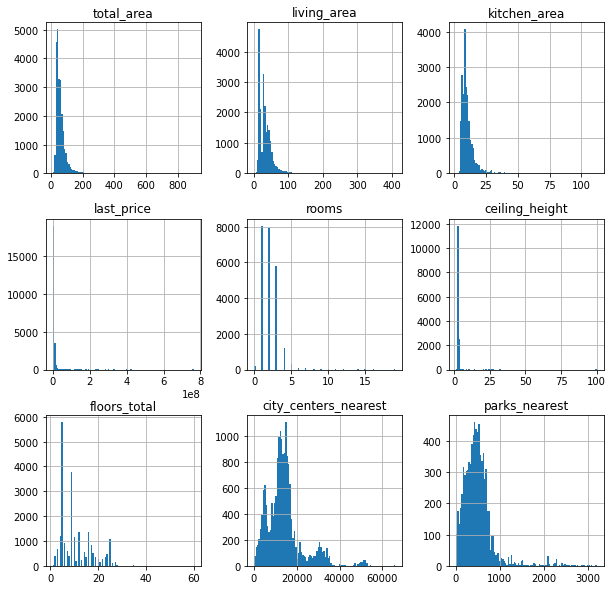

In [91]:
data[['total_area', 'living_area', 'kitchen_area', 'last_price', 'rooms', 'ceiling_height', 'floor_type', 'floors_total', 'city_centers_nearest', 'parks_nearest']].hist(figsize=(10,10), bins=100)

Во многих параметрах, судя по графикам, есть выбросы, мешающие провести анализ.

##### Общая площадь (`total_area`)

Построим гистограмму и диаграмму рассеяния

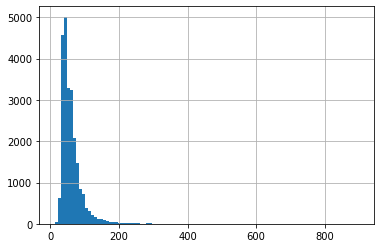

<AxesSubplot:>

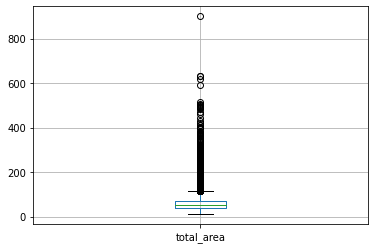

In [92]:
data['total_area'].hist(bins=100)
plt.show()
data['total_area'].plot(kind='box', grid=True)

In [93]:
data['total_area'].describe()

count    23699.000000
mean        60.348651
std         35.654083
min         12.000000
25%         40.000000
50%         52.000000
75%         69.900000
max        900.000000
Name: total_area, dtype: float64

Основная часть данных столбца до 200 м, но есть много выбросов вплоть до 900м.

Выведем 20 строк с самым большим значением `total_area`

In [94]:
pd.set_option('display.max_rows', None)
display(data.sort_values('total_area', ascending=False).head(20))
pd.reset_option('display.max_rows')

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,parks_category,ponds_category,square_meter_price,week_day_exposition,month_exposition,year_exposition,floor_type,city_centers_kilometers
19540,8,420000000,900.00,2017-12-06,12,2.80,25.0,409.7,25,NaN,False,False,112.00,0,Санкт-Петербург,30706.0,7877.0,0,NaN,2,318.0,106.0,D,A,466666.67,2,12,2017,last,8.0
12859,20,140000000,631.20,2019-04-09,7,3.90,4.0,322.3,4,NaN,False,False,19.50,1,Санкт-Петербург,25707.0,4972.0,0,NaN,2,210.0,NaN,D,A,221799.75,1,4,2019,last,5.0
3117,19,140000000,631.00,2019-03-30,7,NaN,5.0,NaN,5,NaN,False,False,60.00,0,Санкт-Петербург,25707.0,4972.0,0,NaN,2,210.0,NaN,D,A,221870.05,5,3,2019,last,5.0
15651,20,300000000,618.00,2017-12-18,7,3.40,7.0,258.0,5,NaN,False,False,70.00,0,Санкт-Петербург,32440.0,5297.0,0,NaN,2,198.0,111.0,D,A,485436.89,0,12,2017,other,5.0
5358,20,65000000,590.00,2019-02-14,15,3.50,6.0,409.0,3,NaN,False,False,100.00,0,Санкт-Петербург,24447.0,4666.0,1,767.0,0,NaN,14.0,B,C,110169.49,3,2,2019,other,5.0
4237,1,50000000,517.00,2017-10-14,7,NaN,4.0,332.0,3,NaN,False,False,22.00,0,Санкт-Петербург,22835.0,1847.0,2,477.0,2,540.0,NaN,A,A,96711.80,5,10,2017,other,2.0
8018,20,84000000,507.00,2015-12-17,5,4.45,7.0,301.5,7,True,False,False,45.50,1,Санкт-Петербург,NaN,5735.0,2,110.0,0,NaN,1078.0,A,C,165680.47,3,12,2015,last,6.0
5893,3,230000000,500.00,2017-05-31,6,NaN,7.0,NaN,7,NaN,False,False,40.00,0,Санкт-Петербург,32440.0,5297.0,0,NaN,2,198.0,50.0,D,A,460000.00,2,5,2017,last,5.0
15016,8,150000000,500.00,2016-01-13,4,3.20,7.0,NaN,7,NaN,False,False,NaN,0,Санкт-Петербург,33058.0,6150.0,3,209.0,3,531.0,303.0,A,A,300000.00,2,1,2016,last,6.0
12401,20,91500000,495.00,2017-06-19,7,4.65,7.0,347.5,7,NaN,False,False,25.00,0,Санкт-Петербург,NaN,5735.0,2,110.0,0,NaN,14.0,A,C,184848.48,0,6,2017,last,6.0


Все 20 квартир с самой большой площадью находятся в Санкт-Петербурге и выглядат правдоподобно, следовательно следует рассматривать квартиры в Питере и области отдельно. Создадим 2 отдельных датафрейма для этого.

In [95]:
spb = data.loc[data['locality_name'] == 'Санкт-Петербург'].reset_index(drop=True)
oblast = data.loc[data['locality_name'] != 'Санкт-Петербург'].reset_index(drop=True)
display(spb)
oblast

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,parks_category,ponds_category,square_meter_price,week_day_exposition,month_exposition,year_exposition,floor_type,city_centers_kilometers
0,20,13000000,108.00,2019-03-07,3,2.70,16.0,51.0,8,NaN,False,False,25.00,0,Санкт-Петербург,18863.0,16028.0,1,482.0,2,755.0,NaN,A,B,120370.37,3,3,2019,other,16.0
1,10,5196000,56.00,2015-08-20,2,NaN,5.0,34.3,4,NaN,False,False,8.30,0,Санкт-Петербург,21741.0,13933.0,1,90.0,2,574.0,558.0,A,A,92785.71,3,8,2015,other,14.0
2,0,64900000,159.00,2015-07-24,3,NaN,14.0,NaN,9,NaN,False,False,NaN,0,Санкт-Петербург,28098.0,6800.0,2,84.0,3,234.0,424.0,A,A,408176.10,4,7,2015,other,7.0
3,2,10000000,100.00,2018-06-19,2,3.03,14.0,32.0,13,NaN,False,False,41.00,0,Санкт-Петербург,31856.0,8098.0,2,112.0,1,48.0,121.0,A,A,100000.00,1,6,2018,other,8.0
4,5,7915000,71.60,2019-04-18,2,NaN,24.0,NaN,22,NaN,False,False,18.90,2,Санкт-Петербург,23982.0,11634.0,0,NaN,0,NaN,NaN,D,C,110544.69,3,4,2019,other,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15716,13,3550000,35.30,2018-02-28,1,2.86,15.0,16.3,4,NaN,False,False,9.10,2,Санкт-Петербург,17284.0,16081.0,1,353.0,2,652.0,29.0,A,B,100566.57,2,2,2018,other,16.0
15717,3,5500000,52.00,2018-07-19,2,NaN,5.0,31.0,2,NaN,False,False,6.00,0,Санкт-Петербург,20151.0,6263.0,1,300.0,0,NaN,15.0,A,C,105769.23,3,7,2018,other,6.0
15718,11,9470000,72.90,2016-10-13,2,2.75,25.0,40.3,7,NaN,False,False,10.60,1,Санкт-Петербург,19424.0,4489.0,0,NaN,1,806.0,519.0,D,B,129903.98,3,10,2016,other,4.0
15719,9,9700000,133.81,2017-03-21,3,3.70,5.0,73.3,3,NaN,False,False,13.83,0,Санкт-Петербург,24665.0,4232.0,1,796.0,3,381.0,NaN,B,A,72490.85,1,3,2017,other,4.0


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,parks_category,ponds_category,square_meter_price,week_day_exposition,month_exposition,year_exposition,floor_type,city_centers_kilometers
0,7,3350000,40.40,2018-12-04,1,NaN,11.0,18.60,1,NaN,False,False,11.00,2,Шушары,12817.0,18603.0,0,NaN,0,NaN,81.0,D,C,82920.79,1,12,2018,first,19.0
1,10,2890000,30.40,2018-09-10,1,NaN,12.0,14.40,5,NaN,False,False,9.10,0,Янино-1,NaN,NaN,0,NaN,0,NaN,55.0,D,C,95065.79,0,9,2018,other,NaN
2,6,3700000,37.30,2017-11-02,1,NaN,26.0,10.60,6,NaN,False,False,14.40,1,Парголово,52996.0,19143.0,0,NaN,0,NaN,155.0,D,C,99195.71,3,11,2017,other,19.0
3,20,2900000,33.16,2018-05-23,1,NaN,27.0,15.43,26,NaN,False,False,8.81,0,Мурино,NaN,NaN,0,NaN,0,NaN,189.0,D,C,87454.76,2,5,2018,other,NaN
4,9,3300000,44.00,2018-08-27,2,NaN,5.0,31.00,4,False,False,False,6.00,1,Ломоносов,48252.0,51677.0,0,NaN,0,NaN,7.0,D,C,75000.00,0,8,2018,other,52.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7973,2,1350000,30.00,2017-07-07,1,NaN,5.0,17.50,4,NaN,False,False,6.00,0,Тихвин,NaN,NaN,0,NaN,0,NaN,413.0,D,C,45000.00,4,7,2017,other,NaN
7974,9,4600000,62.40,2016-08-05,3,2.6,9.0,40.00,8,NaN,False,False,8.00,0,Петергоф,45602.0,34104.0,1,352.0,1,675.0,239.0,A,B,73717.95,4,8,2016,other,34.0
7975,14,3100000,59.00,2018-01-15,3,NaN,5.0,38.00,4,NaN,False,False,8.50,0,Тосно,NaN,NaN,0,NaN,0,NaN,45.0,D,C,52542.37,0,1,2018,other,NaN
7976,18,2500000,56.70,2018-02-11,2,NaN,3.0,29.70,1,NaN,False,False,NaN,0,Рождествено,NaN,NaN,0,NaN,0,NaN,NaN,D,C,44091.71,6,2,2018,first,NaN


Посмотрим распределение площади в Питере и области

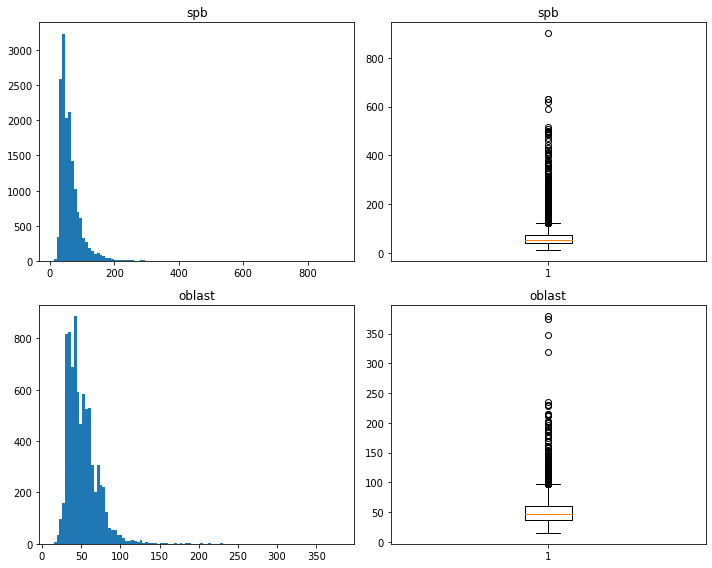

In [96]:

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axes[0, 0].hist(spb['total_area'], bins=100)
axes[0, 0].set_title('spb')

axes[0, 1].boxplot(spb['total_area'])
axes[0, 1].set_title('spb')

axes[1, 0].hist(oblast['total_area'], bins=100)
axes[1, 0].set_title('oblast')

axes[1, 1].boxplot(oblast['total_area'])
axes[1, 1].set_title('oblast')

plt.tight_layout()
plt.show()

Графики похожи, но в Питере данных больше, основная часть находиться в до 200 (в области до 125), выбросы есть в обоих датасетах.

Посмотрим на 20 квартир в области с самой большой площадью.

In [97]:
oblast.sort_values('total_area', ascending=False).head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,parks_category,ponds_category,square_meter_price,week_day_exposition,month_exposition,year_exposition,floor_type,city_centers_kilometers
1714,20,35000000,380.0,2017-08-17,6,NaN,3.0,198.0,2,NaN,False,False,50.0,0,Пушкин,18490.0,30643.0,1,527.0,1,668.0,15.0,B,B,92105.26,3,8,2017,other,31.0
6788,8,42000000,374.0,2017-04-09,7,NaN,4.0,239.4,3,NaN,False,False,51.0,0,Пушкин,15595.0,27749.0,3,62.0,3,274.0,9.0,A,A,112299.47,6,4,2017,other,28.0
3545,13,36900000,347.5,2017-09-14,8,NaN,4.0,160.0,1,NaN,False,False,40.0,0,Колпино,28346.0,34132.0,1,1809.0,2,241.0,249.0,C,A,106187.05,3,9,2017,first,34.0
3721,3,14000000,320.0,2017-09-27,6,NaN,3.0,190.0,3,NaN,False,False,28.0,0,Красное Село,26020.0,29445.0,1,569.0,0,NaN,8.0,B,C,43750.00,2,9,2017,last,29.0
2051,20,13200000,236.0,2018-07-20,4,2.80,3.0,78.0,3,NaN,False,False,19.0,1,Сертолово,NaN,NaN,0,NaN,0,NaN,42.0,D,C,55932.20,4,7,2018,last,NaN
194,20,25717300,230.1,2015-01-21,3,NaN,3.0,130.0,1,NaN,False,False,26.1,1,Пушкин,16877.0,29030.0,2,676.0,3,278.0,1441.0,B,A,111765.75,2,1,2015,first,29.0
2488,3,11000000,230.0,2018-03-01,5,2.50,2.0,NaN,2,NaN,False,False,NaN,0,Хязельки,NaN,NaN,0,NaN,0,NaN,419.0,D,C,47826.09,3,3,2018,last,NaN
1688,8,29000000,228.0,2016-12-29,4,3.50,3.0,141.0,2,NaN,False,False,40.4,1,Пушкин,14651.0,26805.0,3,421.0,3,237.0,572.0,A,A,127192.98,3,12,2016,other,27.0
3265,20,15500000,215.2,2018-10-06,4,NaN,5.0,94.0,2,NaN,False,False,16.4,0,Стрельна,28815.0,24004.0,0,NaN,1,969.0,NaN,D,B,72026.02,5,10,2018,other,24.0
697,23,21000000,215.0,2017-11-11,4,NaN,5.0,55.0,2,NaN,False,False,17.0,0,Красное Село,24842.0,28266.0,1,311.0,1,1009.0,14.0,A,B,97674.42,5,11,2017,other,28.0


Данные выглядят правдоподобно, но для равномерности данных избавимся от выбросов по общей площади в Санкт-Петербурге после 200, а в области после 125.

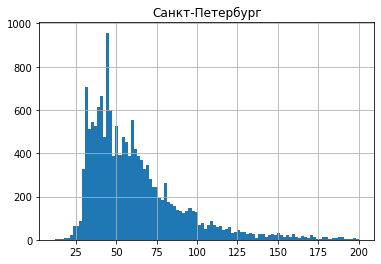

Text(0.5, 1.0, 'Область')

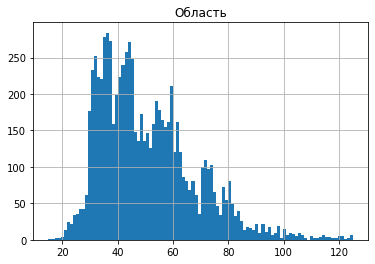

In [98]:
data_2 = data.query('(locality_name == "Санкт-Петербург" and total_area <= 200) or (locality_name != "Санкт-Петербург" and total_area <= 125)')
data_2.loc[data['locality_name'] == 'Санкт-Петербург', 'total_area'].hist(bins=100)
plt.title('Санкт-Петербург')
plt.show()
data_2.loc[data['locality_name'] != 'Санкт-Петербург', 'total_area'].hist(bins=100)
plt.title('Область')

Графики стали более ровными

##### Жилая площадь (`living_area`)

Пострим гистограмму распределения жилой площади

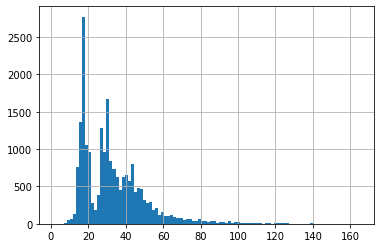

count    21555.000000
mean        33.158919
std         17.221636
min          2.000000
25%         18.600000
50%         30.000000
75%         42.000000
max        164.700000
Name: living_area, dtype: float64

In [99]:
data_2['living_area'].hist(bins=100)
plt.show()
data_2['living_area'].describe()

Много выбросов, посмотрим на 20 квартир с самой высокой жилой площадью

In [100]:
data_2.sort_values('living_area').head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,parks_category,ponds_category,square_meter_price,week_day_exposition,month_exposition,year_exposition,floor_type,city_centers_kilometers
13915,20,6350000,52.0,2018-02-06,2,3.00,6.0,2.0,2,NaN,False,False,9.0,0,Санкт-Петербург,32453.0,6521.0,0,NaN,1,1012.0,91.0,D,B,122115.38,1,2,2018,other,7.0
21758,0,2330000,23.0,2018-01-01,0,NaN,24.0,2.0,22,NaN,True,False,NaN,0,Мурино,NaN,NaN,0,NaN,0,NaN,66.0,D,C,101304.35,0,1,2018,other,NaN
23574,14,64990000,139.0,2015-11-24,3,3.00,8.0,3.0,8,NaN,False,False,16.0,1,Санкт-Петербург,33255.0,5975.0,1,630.0,3,100.0,280.0,B,A,467553.96,1,11,2015,last,6.0
3242,7,4440000,41.0,2017-07-02,1,NaN,17.0,3.0,17,NaN,False,False,11.0,0,Санкт-Петербург,19272.0,13073.0,0,NaN,0,NaN,216.0,D,C,108292.68,6,7,2017,last,13.0
17582,11,2680000,22.0,2018-08-11,0,NaN,25.0,5.0,8,NaN,True,False,NaN,2,Санкт-Петербург,22735.0,11618.0,1,835.0,1,652.0,70.0,B,B,121818.18,5,8,2018,other,12.0
21943,15,6100000,77.6,2019-02-28,4,2.50,9.0,5.4,1,NaN,False,False,9.8,0,Санкт-Петербург,29338.0,11270.0,1,584.0,0,NaN,33.0,B,C,78608.25,3,2,2019,first,11.0
16431,13,3799000,31.0,2018-04-12,1,2.60,5.0,6.0,1,NaN,False,False,17.0,0,Санкт-Петербург,32177.0,4826.0,1,430.0,0,NaN,168.0,A,C,122548.39,3,4,2018,first,5.0
19251,19,4050000,33.0,2018-10-15,1,2.50,22.0,6.5,21,NaN,False,False,18.0,0,Санкт-Петербург,9258.0,10592.0,1,458.0,0,NaN,44.0,A,C,122727.27,0,10,2018,other,11.0
20994,7,8900000,50.6,2018-10-22,2,2.50,7.0,8.0,3,NaN,False,False,31.0,0,Санкт-Петербург,12771.0,8301.0,1,173.0,3,126.0,NaN,A,A,175889.33,0,10,2018,other,8.0
23208,12,4800000,37.0,2016-02-24,1,NaN,14.0,8.0,11,NaN,False,False,22.0,0,Санкт-Петербург,27838.0,12387.0,2,358.0,1,950.0,139.0,A,B,129729.73,2,2,2016,other,12.0


Практически все они находятся в Санкт-Петербурге, пострим гистограмму отдельно для Питера и области.

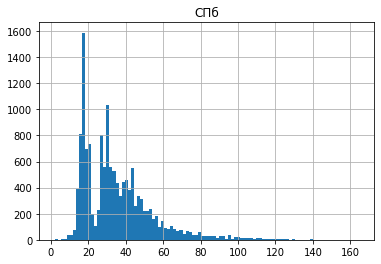

Text(0.5, 1.0, 'Область')

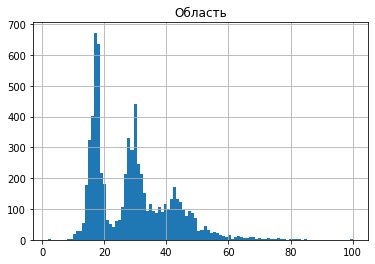

In [101]:
data_2.loc[data_2['locality_name'] == 'Санкт-Петербург', 'living_area'].hist(bins=100)
plt.title('СПб')
plt.show()
data_2.loc[data_2['locality_name'] != 'Санкт-Петербург', 'living_area'].hist(bins=100)
plt.title('Область')

Выведем 20 квартир с самой большой жилой площадью в Питере и области.

In [102]:
display(data_2.query('locality_name == "Санкт-Петербург"').sort_values('living_area', ascending=False).head(20))
data_2.query('locality_name != "Санкт-Петербург"').sort_values('living_area', ascending=False).head(20)

,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,parks_category,ponds_category,square_meter_price,week_day_exposition,month_exposition,year_exposition,floor_type,city_centers_kilometers
21676,20,23600000,181.3,2017-07-10,4,3.50,7.0,164.7,7,NaN,False,False,10.7,1,Санкт-Петербург,26902.0,5605.0,3,484.0,1,305.0,NaN,A,A,130170.99,0,7,2017,last,6.0
22904,4,19500000,190.0,2017-04-27,6,NaN,4.0,159.6,3,NaN,False,False,21.0,0,Санкт-Петербург,20965.0,814.0,0,NaN,2,267.0,87.0,D,A,102631.58,3,4,2017,other,1.0
9392,3,19500000,195.7,2018-02-22,6,3.21,5.0,150.8,5,NaN,False,False,17.7,0,Санкт-Петербург,23932.0,4195.0,1,500.0,0,NaN,125.0,A,C,99642.31,3,2,2018,last,4.0
20264,17,119000000,187.6,2017-07-10,4,6.00,7.0,147.0,7,NaN,False,False,15.6,0,Санкт-Петербург,26902.0,5605.0,3,484.0,1,305.0,259.0,A,A,634328.36,0,7,2017,last,6.0
11438,26,34979000,198.0,2017-11-23,5,NaN,5.0,147.0,3,NaN,False,False,16.0,0,Санкт-Петербург,20767.0,1085.0,3,542.0,2,126.0,90.0,B,A,176661.62,3,11,2017,other,1.0
18790,0,15000000,197.2,2016-01-13,5,3.78,5.0,145.4,3,False,False,False,17.5,0,Санкт-Петербург,24089.0,4154.0,1,634.0,2,516.0,389.0,B,A,76064.91,2,1,2016,other,4.0
22420,12,25000000,196.0,2016-11-04,7,3.50,6.0,145.0,5,NaN,False,False,17.0,1,Санкт-Петербург,25083.0,3658.0,1,552.0,0,NaN,NaN,B,C,127551.02,4,11,2016,other,4.0
16199,7,19000000,189.0,2017-05-09,6,3.23,6.0,145.0,2,NaN,False,False,NaN,0,Санкт-Петербург,24187.0,2980.0,2,73.0,3,134.0,480.0,A,A,100529.10,1,5,2017,other,3.0
4710,0,18000000,184.0,2016-02-26,5,NaN,7.0,142.0,5,NaN,False,False,15.0,0,Санкт-Петербург,22656.0,4288.0,1,556.0,0,NaN,175.0,B,C,97826.09,4,2,2016,other,4.0
12549,10,14500000,165.0,2017-02-02,6,NaN,6.0,140.0,4,NaN,False,False,19.0,0,Санкт-Петербург,20561.0,1827.0,3,427.0,3,251.0,180.0,A,A,87878.79,3,2,2017,other,2.0


,total_images,last_price,total_area,first_day_exposition,rooms,ceiling_height,floors_total,living_area,floor,is_apartment,studio,open_plan,kitchen_area,balcony,locality_name,airports_nearest,city_centers_nearest,parks_around3000,parks_nearest,ponds_around3000,ponds_nearest,days_exposition,parks_category,ponds_category,square_meter_price,week_day_exposition,month_exposition,year_exposition,floor_type,city_centers_kilometers
15451,11,5000000,117.00,2018-02-06,3,3.00,5.0,100.00,3,NaN,False,False,10.00,0,Выборг,NaN,NaN,0,NaN,0,NaN,63.0,D,C,42735.04,1,2,2018,other,NaN
9887,20,4940790,104.00,2017-12-20,4,2.70,6.0,85.00,5,NaN,False,False,NaN,5,Мичуринское,NaN,NaN,0,NaN,0,NaN,NaN,D,C,47507.60,2,12,2017,other,NaN
16094,4,5650000,114.50,2017-10-11,3,2.75,9.0,83.00,5,NaN,False,False,13.60,1,Синявино,NaN,NaN,0,NaN,0,NaN,22.0,D,C,49344.98,2,10,2017,other,NaN
8750,11,5800000,120.80,2016-06-08,3,NaN,9.0,82.10,5,NaN,False,False,13.80,0,Синявино,NaN,NaN,0,NaN,0,NaN,78.0,D,C,48013.25,2,6,2016,other,NaN
23622,15,7490000,114.00,2018-08-13,4,3.15,4.0,81.30,4,NaN,False,False,12.00,0,Выборг,NaN,NaN,0,NaN,0,NaN,245.0,D,C,65701.75,0,8,2018,last,NaN
10351,4,5380992,110.72,2015-10-09,4,NaN,NaN,80.39,4,NaN,False,False,NaN,0,Токсово,NaN,NaN,0,NaN,0,NaN,251.0,D,C,48600.00,4,10,2015,other,NaN
14655,14,3950000,119.30,2018-09-11,3,2.80,3.0,80.00,3,NaN,False,False,18.70,0,Кикерино,NaN,NaN,0,NaN,0,NaN,209.0,D,C,33109.81,1,9,2018,last,NaN
23100,5,6390000,125.00,2016-02-01,3,3.00,4.0,80.00,3,False,False,False,14.00,1,Ломоносов,49343.0,52768.0,2,407.0,3,410.0,179.0,A,A,51120.00,0,2,2016,other,53.0
11424,9,6650000,94.00,2018-12-12,3,NaN,10.0,80.00,4,NaN,False,False,9.00,0,Мурино,NaN,NaN,0,NaN,0,NaN,NaN,D,C,70744.68,2,12,2018,other,NaN
22963,16,3150000,102.00,2018-06-26,5,NaN,9.0,78.00,8,NaN,False,False,24.00,1,Кингисепп,NaN,NaN,0,NaN,0,NaN,57.0,D,C,30882.35,1,6,2018,other,NaN


Данные выглядят правдоподобно. На гистаграммах также видны провалы в районе 22 и 35, но это может быть вызвано популярностью конкретных планировок. Обрежем выбросы по жилой площади в Санкт-Петербурге после 80, в области после 60.

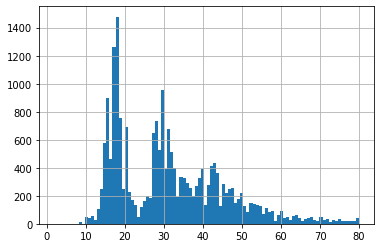

{'whiskers': [<matplotlib.lines.Line2D at 0x7f1112afadf0>,
 'caps': [<matplotlib.lines.Line2D at 0x7f11131a2d60>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f1112afa670>],
 'medians': [<matplotlib.lines.Line2D at 0x7f11131b1e20>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f1113206850>],
 'means': []}

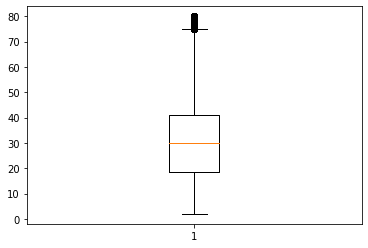

In [103]:
data_2 = data_2.query('(locality_name == "Санкт-Петербург" and living_area <= 80) or (locality_name != "Санкт-Петербург" and living_area <= 60)')
data_2['living_area'].hist(bins=100)
plt.show()
plt.boxplot(data_2['living_area'])

Данные на графиках стали распределены равномернее.

##### Площадь кухни (`kitchen_area`)

Пострим гистограмму распределения площади кухни.

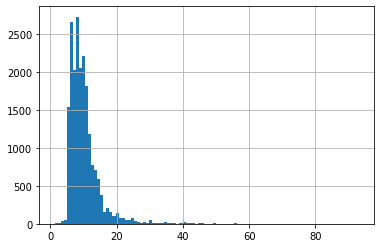

count    20195.000000
mean        10.133612
std          5.047382
min          1.300000
25%          7.000000
50%          9.000000
75%         11.500000
max         93.200000
Name: kitchen_area, dtype: float64

In [104]:
data_2['kitchen_area'].hist(bins=100)
plt.show()
data_2['kitchen_area'].describe()

Много выбросов, пострим гистограмму отдельно Санкт-Петербурга и области.

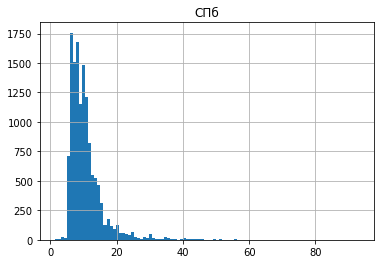

Text(0.5, 1.0, 'Область')

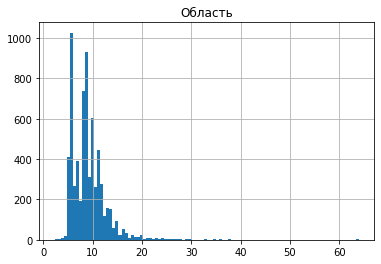

In [105]:
data_2.loc[data_2['locality_name'] == 'Санкт-Петербург', 'kitchen_area'].hist(bins=100)
plt.title('СПб')
plt.show()
data_2.loc[data_2['locality_name'] != 'Санкт-Петербург', 'kitchen_area'].hist(bins=100)
plt.title('Область')

Обрежем выбросы по площади кухни в Питере после 25, в области после 20.

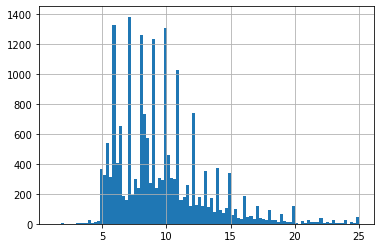

{'whiskers': [<matplotlib.lines.Line2D at 0x7f111256cb20>,
 'caps': [<matplotlib.lines.Line2D at 0x7f111257c220>,
 'boxes': [<matplotlib.lines.Line2D at 0x7f111256c7c0>],
 'medians': [<matplotlib.lines.Line2D at 0x7f111257c8e0>],
 'fliers': [<matplotlib.lines.Line2D at 0x7f111257cc40>],
 'means': []}

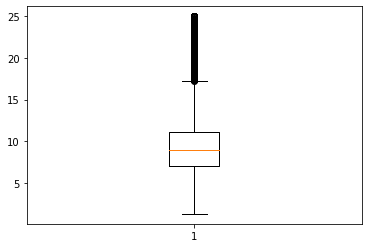

In [106]:
data_2 = data_2.query('(locality_name == "Санкт-Петербург" and kitchen_area <= 25) or (locality_name != "Санкт-Петербург" and kitchen_area <= 20)')
data_2['kitchen_area'].hist(bins=100)
plt.show()
plt.boxplot(data_2['kitchen_area'])

Данные на графиках стали распределены более равномерно.

##### Цена объекта (`total_price`)

Пострим гистограмму распределения общей цены во всём датасете и отдельно для Санкт-Петербурга и области.

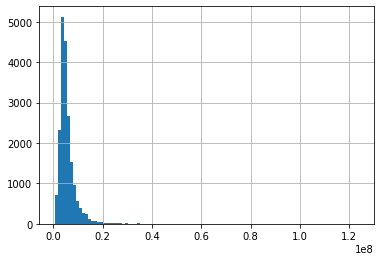

count    1.977800e+04
mean     5.434627e+06
std      3.822762e+06
min      4.300000e+05
25%      3.420000e+06
50%      4.550000e+06
75%      6.300000e+06
max      1.240000e+08
Name: last_price, dtype: float64

In [107]:
data_2['last_price'].hist(bins=100)
plt.show()
data_2['last_price'].describe()

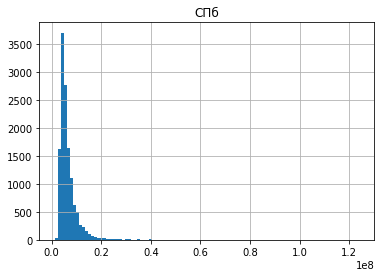

Text(0.5, 1.0, 'Область')

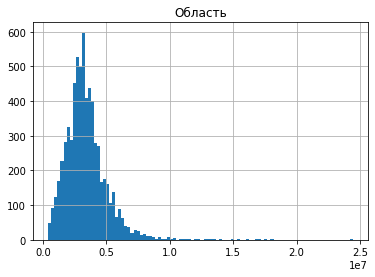

In [108]:
data_2.loc[data_2['locality_name'] == 'Санкт-Петербург', 'last_price'].hist(bins=100)
plt.title('СПб')
plt.show()
data_2.loc[data_2['locality_name'] != 'Санкт-Петербург', 'last_price'].hist(bins=100)
plt.title('Область')

Обрежем выбросы по цене объекта в Питере после 0.2e8, в области после 1e7.

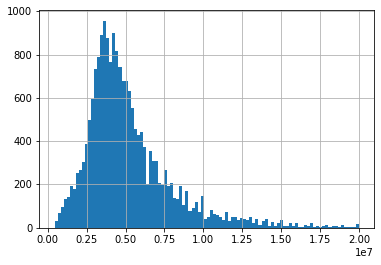

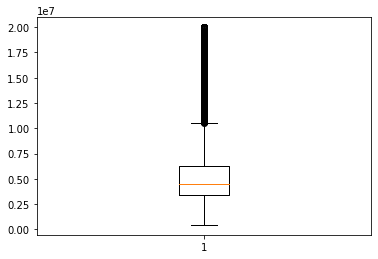

In [109]:
data_2 = data_2.query('(locality_name == "Санкт-Петербург" and last_price <= 0.2e8) or (locality_name != "Санкт-Петербург" and last_price <= 1e7)')
data_2['last_price'].hist(bins=100)
plt.show()
plt.boxplot(data_2['last_price'])
plt.show()

Данные на графиках стали распределены равномернее.

##### Количество комнат (`rooms`)

Пострим гистограмму распределения количества комнат во всём датасете и отдельно для Санкт-Петербурга и области.

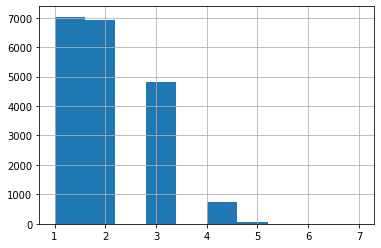

count    19579.000000
mean         1.972930
std          0.888619
min          1.000000
25%          1.000000
50%          2.000000
75%          3.000000
max          7.000000
Name: rooms, dtype: float64

In [110]:
data_2['rooms'].hist()
plt.show()
data_2['rooms'].describe()

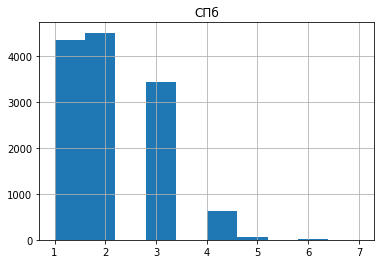

Text(0.5, 1.0, 'Область')

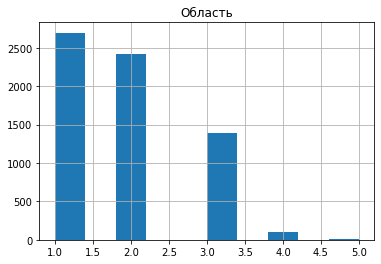

In [111]:
data_2.loc[data_2['locality_name'] == 'Санкт-Петербург', 'rooms'].hist()
plt.title('СПб')
plt.show()
data_2.loc[data_2['locality_name'] != 'Санкт-Петербург', 'rooms'].hist()
plt.title('Область')

Уберём из выборки квартиры с количеством комнат больше 5, чтобы данные были более равномерными.

In [112]:
data_2 = data_2.query('rooms <= 5')

##### Высота потолков (`ceiling_height`)

Пострим гистограмму распределения высоты потолков.

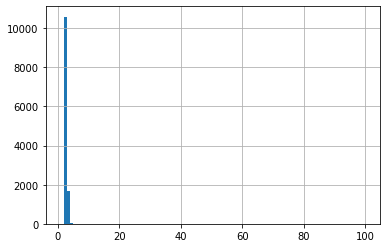

count    12335.000000
mean         2.736293
std          1.268101
min          1.000000
25%          2.500000
50%          2.600000
75%          2.750000
max        100.000000
Name: ceiling_height, dtype: float64

In [113]:
data_2['ceiling_height'].hist(bins=100)
plt.show()
data_2['ceiling_height'].describe()

Есть выбросы вплоть до 100 метров, что неправдоподобно.

Выведем минимальные и максимальные значения.

In [114]:
display(list(data_2.sort_values('ceiling_height', ascending=False)['ceiling_height'].head(10)))
list(data_2.sort_values('ceiling_height')['ceiling_height'].head(10))

[100.0, 32.0, 32.0, 27.5, 27.0, 27.0, 27.0, 27.0, 27.0, 26.0]

[1.0, 1.2, 1.75, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0, 2.0]

Предположим, что адекватная высота потолков от 2 до 8 метров. Тогда неподходящие значения следует удалить. Однако также предположим, что особо большие значения по какой-то причине записаны в дециметрах, поделим значения от 20 на 10 и округлим до 1 знака после запятой, после чего избавимся от выбросов.

In [115]:
# Делим значения больше 20
data_2.loc[data_2['ceiling_height'] >= 20, 'ceiling_height'] = data_2['ceiling_height'] / 10

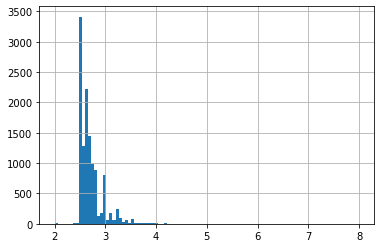

count    12329.000000
mean         2.694966
std          0.247684
min          2.000000
25%          2.500000
50%          2.600000
75%          2.750000
max          8.000000
Name: ceiling_height, dtype: float64

In [116]:
# Удаляем анамалии
data_2 = data_2.query('2 <=ceiling_height <= 8')
data_2['ceiling_height'].hist(bins=100)
plt.show()
data_2['ceiling_height'].describe()

Данные на графике стали распределены более равномерно.

##### Тип этажа квартиры (`floor_type`)

Пострим гистограмму распределения типа этажа.

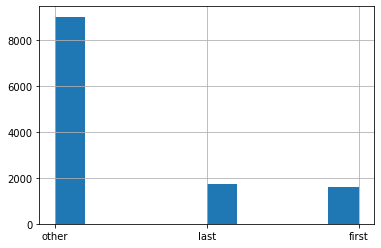

count     12329
unique        3
top       other
freq       9007
Name: floor_type, dtype: object

In [117]:
data_2['floor_type'].hist()
plt.show()
data_2['floor_type'].describe()

Данные адекватно, ожидаемо строк с типом `other` больше всего.

##### Общее количество этажей в доме (`floors_total`)

Пострим гистограмму распределения общего количества этажей.

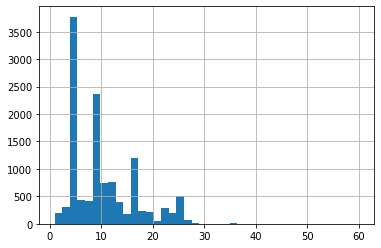

count    12326.000000
mean        10.258884
std          6.183423
min          1.000000
25%          5.000000
50%          9.000000
75%         14.000000
max         60.000000
Name: floors_total, dtype: float64

In [118]:
data_2['floors_total'].hist(bins=40)
plt.show()
data_2['floors_total'].describe()

Есть выбросы вплоть до 60, выражены всплески, что вызвано типовой застройкой. Удалим выбросы после 30

<AxesSubplot:>

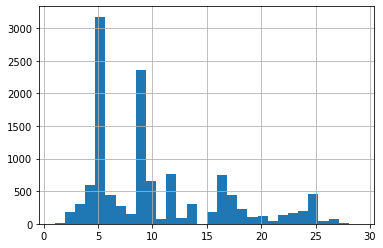

In [119]:
data_2 = data_2.query('floors_total <= 30')
data_2['floors_total'].hist(bins=30)

Данные на графике страли распределены более равномерно.

Вывод
- Практически во всех, рассмотренных параметрах было много выбросов.
- Сравнивая данные Санкт-Петербурга и области, можно сказать, что они немного отличаются количественно, но распределения одинаковы.

#### Изучение скоррости продажи квартир

Пострим гистограмму и диаграмму размаха для времени, ушедшего на продажу квартиры для всего датасета и отдельно для Санкт-Петербурга и области.

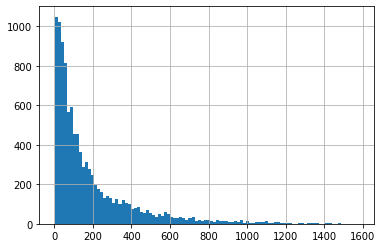

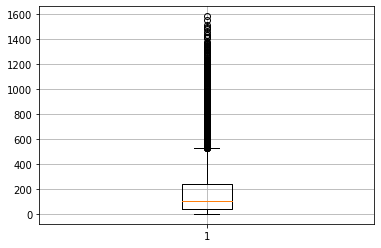

count    10322.000000
mean       185.417458
std        222.070856
min          1.000000
25%         44.000000
50%        103.000000
75%        238.000000
max       1580.000000
Name: days_exposition, dtype: float64

In [120]:
data_2['days_exposition'].hist(bins=100)
plt.show()
plt.boxplot(data_2['days_exposition'].dropna())
plt.grid()
plt.show()
data_2['days_exposition'].describe()

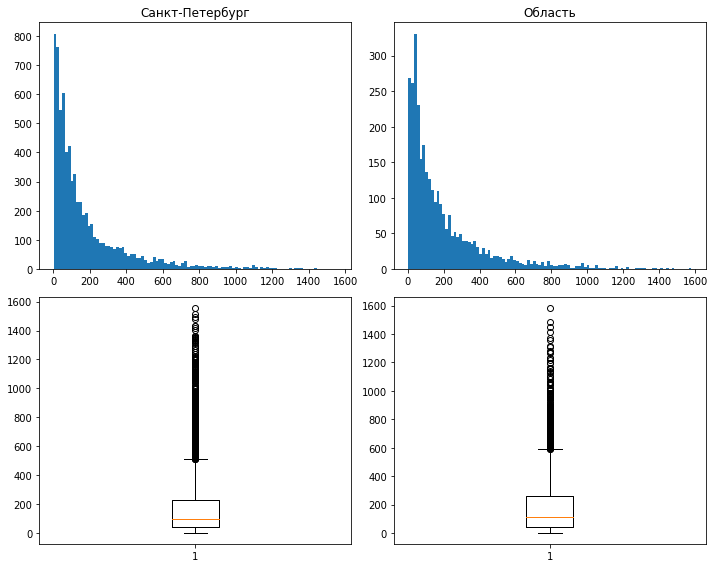

Характерные значения скорости продажи для квартир в Санкт-Петербурге


count    7168.000000
mean      180.067243
std       220.828983
min         1.000000
25%        39.000000
50%        97.000000
75%       228.000000
max      1553.000000
Name: days_exposition, dtype: float64

Характерные значения скорости продажи для квартир в области


count    3154.000000
mean      197.576728
std       224.429017
min         3.000000
25%        45.000000
50%       116.000000
75%       263.000000
max      1580.000000
Name: days_exposition, dtype: float64

In [121]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))

axes[0, 0].hist(data_2.query('locality_name == "Санкт-Петербург"')['days_exposition'], bins=100)
axes[0, 0].set_title('Санкт-Петербург')

axes[0, 1].hist(data_2.query('locality_name != "Санкт-Петербург"')['days_exposition'], bins=100)
axes[0, 1].set_title('Область')

axes[1, 0].boxplot(data_2.query('locality_name == "Санкт-Петербург"')['days_exposition'].dropna())

axes[1, 1].boxplot(data_2.query('locality_name != "Санкт-Петербург"')['days_exposition'].dropna())

plt.tight_layout()
plt.show()

print('Характерные значения скорости продажи для квартир в Санкт-Петербурге')
display(data_2.query('locality_name == "Санкт-Петербург"')['days_exposition'].describe())

print('Характерные значения скорости продажи для квартир в области')
display(data_2.query('locality_name != "Санкт-Петербург"')['days_exposition'].describe())

Распределение скорости продажи квартир похоже на Пуассоновское. Распределение значений в Санкт-Петербурге и области практически не отличаются, но в области на продажу уходит в среднем чуть больше времени. Средние значения - 185, медианное - 103. Много выбросов вплоть до 1580 дней. Необычно долгим временем продажи будем считать сначения за пределами "усов" диаграммы размаха, то есть значения больше 529, а необычно быстрыми - значения меньше первой квартили (<44).

Для дальнейших расчётов оставим только квартиры проданные за период времени от 44 до 529 дней.

In [122]:
data_2 = data_2.query('days_exposition <= 529 and  days_exposition >=44')

#### Определение факторов, больше всего влияющих на общую стоимость

##### Площадь

Рассмотрим зависимость общей стоимости от общей площади, жилой площади и площади кухни и посчитаем корреляцию.

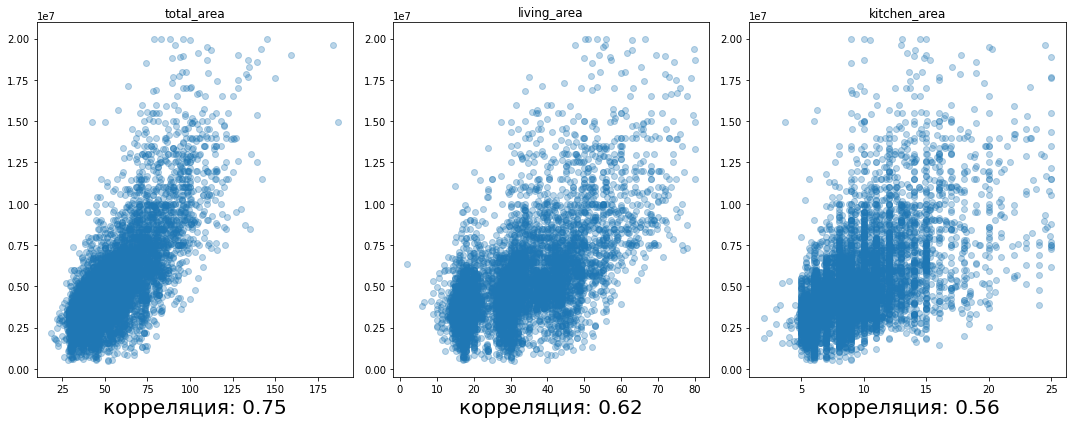

In [123]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))
axes[0].scatter(data_2['total_area'], data_2['last_price'], alpha=0.3)
axes[0].set_title('total_area')
axes[0].set_xlabel(f"корреляция: {round(data_2['total_area'].corr(data_2['last_price']), 2)}", fontsize=20)

axes[1].scatter(data_2['living_area'], data_2['last_price'], alpha=0.3)
axes[1].set_title('living_area')
axes[1].set_xlabel(f"корреляция: {round(data_2['living_area'].corr(data_2['last_price']), 2)}", fontsize=20)

axes[2].scatter(data_2['kitchen_area'], data_2['last_price'], alpha=0.3)
axes[2].set_title('kitchen_area')
axes[2].set_xlabel(f"корреляция: {round(data_2['kitchen_area'].corr(data_2['last_price']), 2)}", fontsize=20)


plt.tight_layout()
plt.show()

Судя по графикам и значениям корреляции, стоимость довольно сильно зависит от площади, но именно от общей, а не жилой площади или площади кухни.

##### Количество комнат

Рассмотрим зависимость общей стоимости от количества комнат (`rooms`), построим диаграммы размаха для всех значений и посчитаем корреляцию.

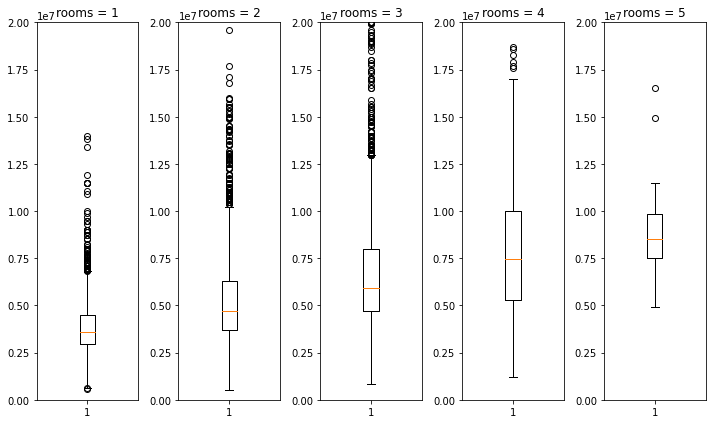

Корреляция: 0.46


In [124]:
fig, axes = plt.subplots(nrows=1, ncols=5, figsize=(10, 6))
axes[0].boxplot(data_2.query('rooms == 1')['last_price'])
axes[0].set_title('rooms = 1')
axes[0].set_ylim(0, 2e7)

axes[1].boxplot(data_2.query('rooms == 2')['last_price'])
axes[1].set_title('rooms = 2')
axes[1].set_ylim(0, 2e7)

axes[2].boxplot(data_2.query('rooms == 3')['last_price'])
axes[2].set_title('rooms = 3')
axes[2].set_ylim(0, 2e7)

axes[3].boxplot(data_2.query('rooms == 4')['last_price'])
axes[3].set_title('rooms = 4')
axes[3].set_ylim(0, 2e7)

axes[4].boxplot(data_2.query('rooms == 5')['last_price'])
axes[4].set_title('rooms = 5')
axes[4].set_ylim(0, 2e7)

plt.tight_layout()
plt.show()

print(f"Корреляция: {round(data_2['rooms'].corr(data_2['last_price']), 2)}")

По графикам можно увидеть, что корреляция между кол-вом комнат и ценой есть, но не слишком большая.

##### Тип этажа

Рассмотрим зависимость цены от типа этажа (`floor_type`), построим диаграммы размаха для всех значений и посчитаем корреляцию.

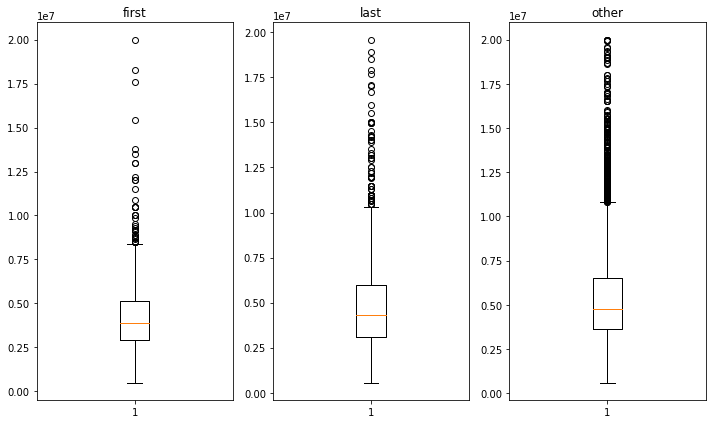

Характерные значения цен квартир, расположеных на первом этаже:


count    9.490000e+02
mean     4.250123e+06
std      2.172476e+06
min      5.000000e+05
25%      2.950000e+06
50%      3.900000e+06
75%      5.150000e+06
max      2.000000e+07
Name: last_price, dtype: float64

Характерные значения цен квартир, расположеных на последнем этаже:


count    9.620000e+02
mean     4.979372e+06
std      2.990066e+06
min      5.600000e+05
25%      3.100000e+06
50%      4.295000e+06
75%      6.000000e+06
max      1.960000e+07
Name: last_price, dtype: float64

Характерные значения цен квартир, расположеных ни на первом ни на втором этаже:


count    5.013000e+03
mean     5.462501e+06
std      2.818234e+06
min      6.000000e+05
25%      3.630000e+06
50%      4.750000e+06
75%      6.500000e+06
max      2.000000e+07
Name: last_price, dtype: float64

In [125]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(10, 6))
axes[0].boxplot(data_2.query('floor_type == "first"')['last_price'])
axes[0].set_title('first')

axes[1].boxplot(data_2.query('floor_type == "last"')['last_price'])
axes[1].set_title('last')

axes[2].boxplot(data_2.query('floor_type == "other"')['last_price'])
axes[2].set_title('other')

plt.tight_layout()
plt.show()

print('Характерные значения цен квартир, расположеных на первом этаже:')
display(data_2.query('floor_type == "first"')['last_price'].describe())

print('Характерные значения цен квартир, расположеных на последнем этаже:')
display(data_2.query('floor_type == "last"')['last_price'].describe())

print('Характерные значения цен квартир, расположеных ни на первом ни на втором этаже:')
display(data_2.query('floor_type == "other"')['last_price'].describe())

По графикам и характерным значениям, можно сказать, что этаж квартиры немного влияет на цену, квартиры на первом и последнем этажах дешевле, что связано с неудобством проживания на этих этажах.

##### Дата размещения

Построим график изменения среднего и медианного значений цены в зависимости от:
- дня недели выставления на продажу (`week_day_exposition`)
- месяца выставления на продажу (`month_exposition`)
- года выставления на продажу (`year_exposition`)

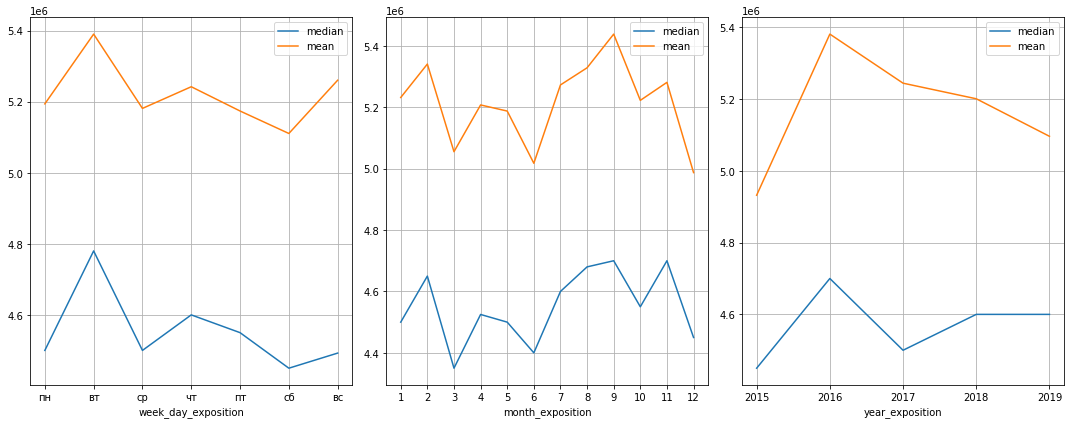

In [126]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(15, 6))

data_2.groupby('week_day_exposition').median()['last_price'].plot(ax=axes[0], label='median')
data_2.groupby('week_day_exposition').mean()['last_price'].plot(ax=axes[0], label='mean')
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(['пн', 'вт', 'ср', 'чт', 'пт', 'сб', 'вс'])
axes[0].legend()
axes[0].grid()

data_2.groupby('month_exposition').median()['last_price'].plot(ax=axes[1], label='median')
data_2.groupby('month_exposition').mean()['last_price'].plot(ax=axes[1], label='mean')
axes[1].set_xticks(range(1, 13))
axes[1].legend()
axes[1].grid()

data_2.groupby('year_exposition').median()['last_price'].plot(ax=axes[2], label='median')
data_2.groupby('year_exposition').mean()['last_price'].plot(ax=axes[2], label='mean')
axes[2].set_xticks(range(2015, 2020))
axes[2].legend()
axes[2].grid()

plt.tight_layout()
plt.show()

Судя по графикам, цена от даты выставления не зависит.

Вывод:

На общую стоимость квартиры влияют общая площадь (корреляция - 0.75), кол-во комнат (корреляция - 0.46) и тип этажа (первый и последний дешевле остальных).

#### Определение населённых пунктов с самой высокой и самой низкой ценой за $м^2$

Построим сводную таблицу по населённым пунктам с кол-вом объявлений и средней ценой за квадратный метр

In [127]:
data_localities = data_2.groupby('locality_name').agg({'square_meter_price': ['count', 'mean']})
data_localities.columns=['count','mean']

Найдём среднюю цену квадратного метра в 10 населённых пунктах с наибольшим числом объявлений

In [128]:
data_localities.sort_values('count', ascending=False).head(10).astype('int')

,count,mean
locality_name,,
Санкт-Петербург,4667,106940
Всеволожск,148,66004
Шушары,129,78132
Мурино,124,85148
Колпино,109,73793
Пушкин,106,97157
Кудрово,89,95187
Парголово,81,88923
Петергоф,74,83140


Найдём пункты с самой высокой и низкой стоимостью квадратного метра

В этих таблицах много населённых пунктов с 1 объявлением, отфильтруем только те населённые пункты, в которых есть хотя бы 10 объявлений.

In [130]:
data_localities_2 = data_localities.query('count >= 10')
print('С самой низкой ценой')
display(data_localities_2.sort_values('mean').head(10).astype('int'))
print('С самой высокой ценой')
display(data_localities_2.sort_values('mean', ascending=False).head(10).astype('int'))

С самой низкой ценой


,count,mean
locality_name,,
Сланцы,25,17424
Волхов,30,35450
Луга,10,36492
Кириши,34,38125
Сиверский,10,41372
Приозерск,27,41549
Мга,11,44794
Кингисепп,10,49459
Лесколово,11,50562


С самой высокой ценой


,count,mean
locality_name,,
Санкт-Петербург,4667,106940
Зеленогорск,10,103884
Сестрорецк,60,98970
Пушкин,106,97157
Кудрово,89,95187
Стрельна,19,89898
Парголово,81,88923
Мурино,124,85148
Петергоф,74,83140


Вывод

По спискам населённых пунктов с самой низкой и высокой ценой за квадратный метр можно заметить, что в списке с самой высокой ценой находятся Санкт-Петербург и населённые пункты, расположенные близко к нему, а населённые пункты в списке с самой низкой ценой расположены по всей Ленобласти. Из этого можно сделать вывод, что около Питера цена за квадратный метр выше.

#### Исследование зависимости стоимости квартиры в Санкт-Петербурге в зависимости от расстояния от центра 

Построим сводную таблицу по километрам от центра с кол-вом объявлений в Санкт-Петербурге

In [131]:
data_spb = data_2.query('locality_name == "Санкт-Петербург"')
data_spb = data_spb.dropna(subset = ['city_centers_kilometers'])
data_spb['city_centers_kilometers'] = data_spb['city_centers_kilometers'].astype('int')

print(data_spb.groupby('city_centers_kilometers').agg({'last_price' : 'count'}))

                         last_price
city_centers_kilometers            
0                                 5
1                                45
2                                70
3                                96
4                               168
5                               219
6                               127
7                               101
8                               185
9                               175
10                              251
11                              364
12                              529
13                              465
14                              435
15                              516
16                              398
17                              249
18                               62
19                               61
20                                8
21                               35
22                               51
23                               23
24                                4
25                          

После 23 километров объявлений становится очень мало, не будем их учитывать

<AxesSubplot:xlabel='city_centers_kilometers'>

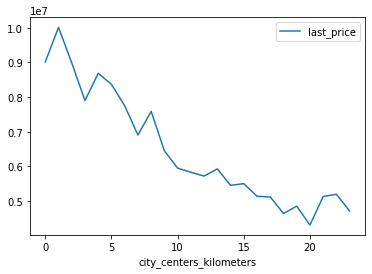

In [132]:
data_spb = data_spb.query('city_centers_kilometers <= 23')
data_spb.groupby('city_centers_kilometers').agg({'last_price' : 'mean'}).astype('int').plot()

По графику можно сказать, что в Санкт-Петербурге с удалением от центра уменьшаяется цена на квартиры.

### Вывод

По полученным данным об объявлениях о продаже квартир была проведена следующая работа:
Предобработка данных:
- Столбец `cityCenters_nearest` переименован в `city_centers_nearest`
- Категоризированы столбцы `parks_nearest` и `ponds_nearest`
- В столбце `balcony` пропуски заменены на нули
- Изменены типы данных в столбцах `first_day_exposition` на datetime, в столбцах `last_price`, `balcony`, `parks_around3000` и `ponds_around3000` на int64
- В столбце `locality_name` у названий населённых пунктов убран их тип, оставленно только название
- Добавлены столбцы `square_meter_price` - цена квадратного метра, `week_day_exposition` - день недели выставления объявления, `month_exposition` - месяц выставления объявления, `year_exposition` - год выставления объявления

Изучение отдельных параметров и фильтрация выбросов:
- Общая площадь (`total_area`) - удалены выбросы в Санкт-Петербурге после 200, в области после 125
- Жилая площадь (`living_area`) - удалены выбросы в Санкт-Петербурге после 80, в области после 60
- Площадь кухни (`kitchen_area`) - удалены выбросы в Санкт-Петербурге после 25, в области после 20
- Цена объекта (`total_price`) - удалены выбросы в Санкт-Петербурге после 0.2e8, в области после 1e7
- Кол-во комнат (`rooms`) - удалены значения больше 5
- Высота потолков (`ceiling_height`) - значения от 20 поделены на 10 (предположительно неверно записано), удалены значения менбше 2 и больше 8
- Общее кол-во этажей (`floors_total`) - удалены выбросы после 30

Определения факторов больше всего влияющих на общую стоимость:
- Площадь сильно влияет на стоимость, причём общая площадь больше влияет (корреляция - 0.75) чем жилая площадь или площадь кухни (корреляции 0.62 и 0.56 соответственно)
- Кол-во комнат влияет на цену, но не так сильно как площадь (корреляция 0.46)
- Тип этажа влияет на цену. На первом и последнем этажах квартиры немного дешевле, что скорее всего связано с неудобством проживания на эти этажах
- Влияние даты размещения на стоимость не выявлено

Населённые пункты с самой большой ценой за $м^2$: 

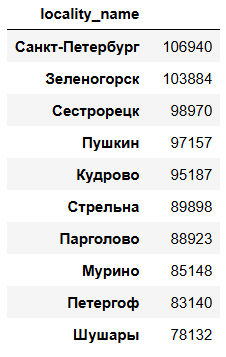

Н

Образ дорогой квартиры:
- Большая площадь
- Много комнат
- Не на первом или последнем этаже

Образ дешёвой квартиры